##### Generalised Linear Model

In [ ]:
#libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# Create ./stan folder if does not exists
if not os.path.exists("./stan"):
    os.mkdir("./stan")

In [21]:
#get the data
data=pd.read_csv("/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data.csv")
print(data.head())
data_donors=pd.read_csv("/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data_donatori.csv")
print(data_donors.head())

#remember to drom TMTC and outliers!!!!   (TO DO)

#data cleaning 
data=data[data['Conta']!='TMTC']
print(data.head())
data_donors=data_donors[data_donors['Conta']!='TMTC']
print(data_donors.head())

  Idx Experiment  Idx Replica Diluizione Idx Replica Condizione Controllo  \
0              1                       1                      A        No   
1              1                       2                      A        No   
2              1                       3                      A        No   
3              1                       1                      A        No   
4              1                       2                      A        No   

   Diluition   IBU  DMSO  Temp Conta  
0         -1  6.25     0    28  TMTC  
1         -1  6.25     0    28  TMTC  
2         -1  6.25     0    28  TMTC  
3         -2  6.25     0    28    36  
4         -2  6.25     0    28    33  
  Idx Experiment  Idx Replica Diluizione  Diluition   IBU  DMSO  Temp  Conta
0              1                       1         -6  6.25     0    28     51
1              1                       2         -6  6.25     0    28     48
2              1                       3         -6  6.25     0    28   

In [22]:
#dimensions and colunms
print("data_trasconjugant shape:", data.shape)
print("data_trasconjugant columns:", data.columns.tolist())
print("data_donors shape:", data_donors.shape)
print("data_donors columns:", data_donors.columns.tolist())

data_trasconjugant shape: (378, 9)
data_trasconjugant columns: ['Idx Experiment', 'Idx Replica Diluizione', 'Idx Replica Condizione', 'Controllo', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Conta']
data_donors shape: (72, 7)
data_donors columns: ['Idx Experiment', 'Idx Replica Diluizione', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Conta']


In [ ]:
#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Controllo':'Control','Conta':'Count'}, inplace=True)

#Modify values in some columns:
#Modify Idx Experiment such that experiments 5 and 6 have the same idx, experiments 7 and 8, experiment 5,6 has the same index as 5 and 6 and experiment 7,8 the same as 7 and 8
#but first convert all to string to avoid problems with mixed types
data['Idx Experiment'] = data['Idx Experiment'].astype(str)
data['Idx Experiment'] = data['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})
#now reconvert to numeric
data['Idx Experiment'] = pd.to_numeric(data['Idx Experiment'])

data_donors['Idx Experiment'] = data_donors['Idx Experiment'].astype(str)
data_donors['Idx Experiment'] = data_donors['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})

#modify control column: convert 'Yes' to 1 and 'No' to 0
data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})
data_donors['Control'] = data_donors['Control'].replace({'Yes': 1, 'No': 0})


#now reconvert to numeric
data_donors['Idx Experiment'] = pd.to_numeric(data_donors['Idx Experiment'])

print(data['Idx Experiment'].unique())
print(data_donors['Idx Experiment'].unique())

#convert to numeric all the others columns I need 
#convert A;B;C in 1;2;3
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].astype(str)
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].replace({'A': '1', 'B':'2','C': '3'})
#now reconvert to numeric
data['Idx Replica Experiment'] = pd.to_numeric(data['Idx Experiment'])

data['Count'] = pd.to_numeric(data['Count'])
data['Idx Replica Diluition'] = pd.to_numeric(data['Idx Replica Diluition'])
data['Diluition'] = pd.to_numeric(data['Diluition'])
data['IBU'] = pd.to_numeric(data['IBU'])
data['DMSO'] = pd.to_numeric(data['DMSO'])
data['Temp'] = pd.to_numeric(data['Temp'])
data_donors['Count'] = pd.to_numeric(data_donors['Count'])
data_donors['Idx Replica Experiment'] = pd.to_numeric(data_donors['Idx Replica Experiment'])    
print(data.dtypes)
print(data_donors.dtypes)



[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]
Idx Experiment              int64
Idx Replica Diluition       int64
Idx Replica Experiment      int64
Controllo                  object
Diluition                   int64
IBU                       float64
DMSO                        int64
Temp                        int64
Count                       int64
dtype: object
Idx Experiment              int64
Idx Replica Experiment      int64
Diluition                   int64
IBU                       float64
DMSO                        int64
Temp                        int64
Count                       int64
dtype: object


In [24]:
#Extract the data we need for the Stan model 
#from trasconjugant dataset
Y=data.Count.values
N=len(Y)
idx_experiment=data['Idx Experiment'].values
I=len(np.unique(idx_experiment))
idx_experiment_replica=data['Idx Replica Experiment'].values
J=len(np.unique(idx_experiment_replica))
dil_trasc=data['Diluition'].values
rho_trasc = np.power(10.0, dil_trasc)


#from donor dataset
D=data_donors.Count.values
M=len(D)
idx_donor_experiment=data_donors['Idx Experiment'].values
dil_donor=data_donors['Diluition'].values
rho_donor=np.power(10.0, dil_donor)


#build design matrix X
IBU=data['IBU'].values
DMSO=data['DMSO'].values
Temp=data['Temp'].values
X=np.column_stack([np.ones_like(Y),IBU,DMSO,Temp])




##### Stan Model 

In [25]:
glm = """
data {
    int<lower=0> N; 
    int<lower=0> M; 
    int<lower=0> p; 
    int<lower=0> I;
    int<lower=0> J;
    array[N] int<lower=0> Y;
    array[M] int<lower=0> D;
    matrix[N, p] X;
    vector[N] rho_trasc;
    vector[M] rho_donor;
    array[N] int idx_experiment;
    array[N] int idx_experiment_replica;
    array[M] int idx_donor_experiment;
}

parameters {
    vector[p] beta;
    matrix[I, J] beta_random;
    vector<lower=0>[I] alpha;
    real<lower=0> sigma_beta;
    real<lower=0> tau;
    real mu_chi;
    real<lower=0> sigma_chi;
}


transformed parameters {
    vector[N] mu;
    for(i in 1:N) {
      mu[i] = alpha[idx_experiment[i]]* exp(row(X, i) * beta + beta_random[idx_experiment[i], idx_experiment_replica[i]]);
    }
}

model {   
    for (s in 1:N) {
        Y[s] ~ poisson(rho_trasc[s] * mu[s]);  

    }

    for (l in 1:M){
        D[l] ~ poisson(rho_donor[l] * alpha[idx_donor_experiment[l]]);
    }

    for (m in 1:I) {
        log(alpha[m])~normal(mu_chi, sigma_chi);

    }
    mu_chi ~ normal(0,5);
    sigma_chi ~ normal(0,1); 
    

    for (k in 1:p) {
        beta[k] ~ normal(0.0, tau);
        
    }

    tau ~ normal(0,1); 
    
    for (i in 1:I) {    
        for (j in 1:J) {
            beta_random[i,j] ~ normal(0, sigma_beta);
        }
    }
    sigma_beta ~ normal(0, 1);  
 
}

generated quantities {
  vector[N] log_lik;
  for (j in 1:N) {
    log_lik[j] = poisson_lpmf(Y[j] | rho_trasc[j]* mu[j]);
  }
}
"""


# Write stan model to file
stan_file = "./stan/glm.stan"
with open(stan_file, "w") as f:
    print(glm, file=f)

# Compile stan model
glm = CmdStanModel(stan_file=stan_file)

19:06:16 - cmdstanpy - INFO - compiling stan file /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm.stan to exe file /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm
19:06:47 - cmdstanpy - INFO - compiled model executable: /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm


In [8]:
import cmdstanpy
print(cmdstanpy.cmdstan_path())


/Users/sararedaelli/.cmdstan/cmdstan-2.37.0


In [26]:
# Input data
glm_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X.shape[1],
    "Y": Y,
    "D": D,
    "X": X,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm_fit = glm.sample(data=glm_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm_data = az.from_cmdstanpy(glm_fit)

19:06:51 - cmdstanpy - INFO - Chain [1] start processing
19:06:51 - cmdstanpy - INFO - Chain [2] start processing
19:06:51 - cmdstanpy - INFO - Chain [3] start processing
19:06:51 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 5000
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag_e (Default)
Chain [2] metric_file =  (Default)
Chain [2] stepsize = 1 (Default)
Chain [2] stepsize_jitter = 0 (Default)
Chain [2] num_chains = 1 (Default)
Chain [2] id = 2
Chain [2] data
Chain [2] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmpmvb81v4a/wmvpsvsg.json
Chain [2] init =

19:17:44 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] 
Chain [2] Elapsed Time: 112.682 seconds (Warm-up)
Chain [2] 540.187 seconds (Sampling)
Chain [2] 652.869 seconds (Total)
Chain [2] 
Chain [2] 


19:17:46 - cmdstanpy - INFO - Chain [1] done processing


...

19:18:37 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 121.461 seconds (Warm-up)
Chain [4] 584.209 seconds (Sampling)
Chain [4] 705.67 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [3] Iteration: 5900 / 6000 [ 98%]  (Sampling)


19:18:48 - cmdstanpy - INFO - Chain [3] done processing
19:18:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'glm.stan', line 63, column 12 to column 53)
Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'glm.stan', line 38, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'glm.stan', line 38, column 8 to column 45)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'glm.stan', line 55, column 8 to column 35)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'glm.stan', line 63, column 12 to column 53)


Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 136.119 seconds (Warm-up)
Chain [3] 580.778 seconds (Sampling)
Chain [3] 716.897 seconds (Total)
Chain [3] 
Chain [3] 


19:18:50 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 2 iterations at max treedepth (0.0%)
	Chain 2 had 6 iterations at max treedepth (0.1%)
	Chain 3 had 133 iterations at max treedepth (2.7%)
	Chain 4 had 22 iterations at max treedepth (0.4%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


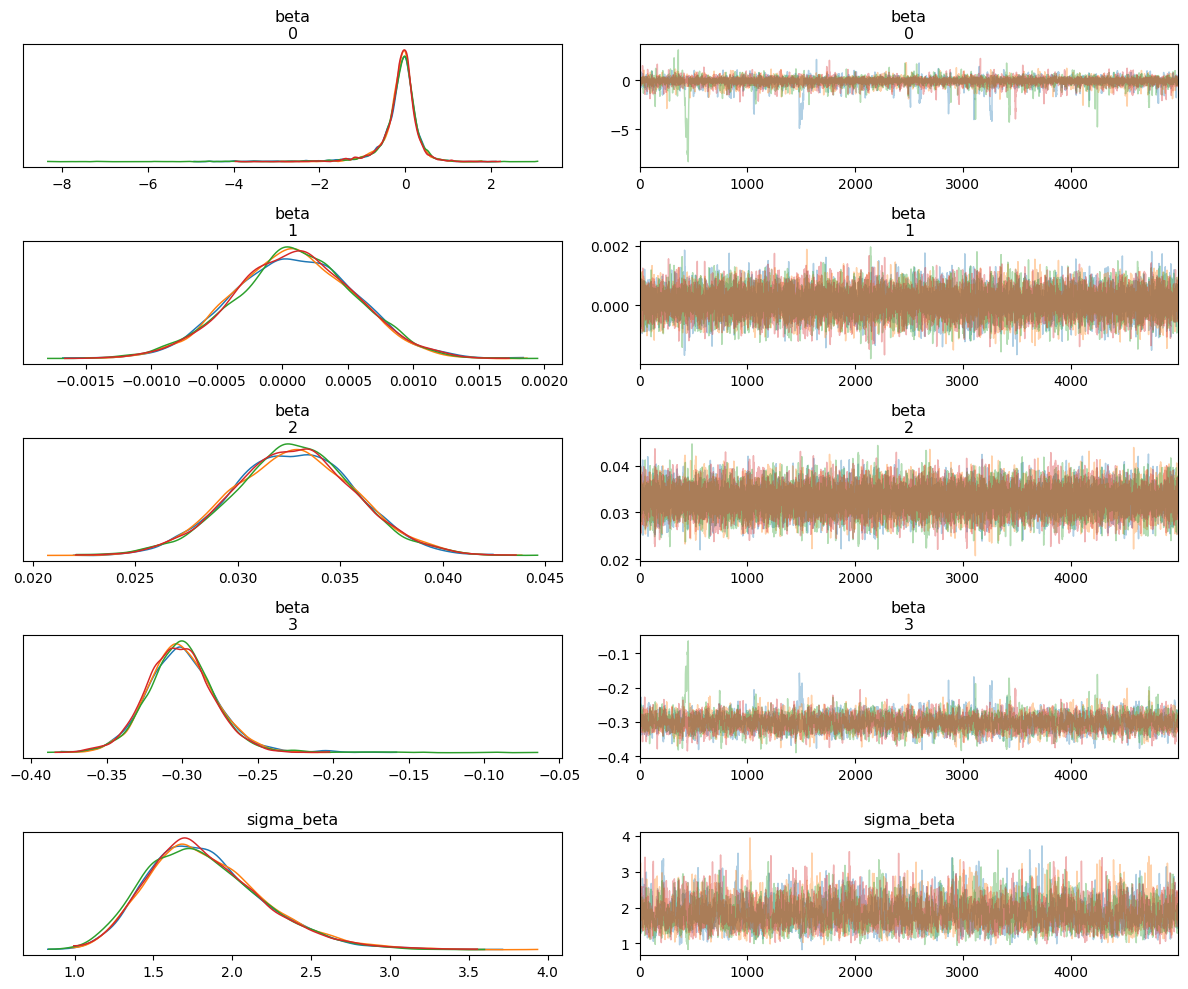

In [27]:
az.plot_trace(poi_glm_data, var_names=["beta", "sigma_beta"], compact=False)
plt.tight_layout()
plt.show()

In [30]:
np.sum(poi_glm_data.sample_stats.diverging)
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68751.500000,0.274671,13.023000,12.946100,68728.900000,68752.200000,68771.900000,2259.46,4384.40,1.00722,1.00207
beta[1],-0.139946,0.013686,0.509879,0.257279,-0.859107,-0.069129,0.391372,5337.32,2550.07,2.37926,1.00108
beta[2],0.000092,0.000003,0.000464,0.000462,-0.000666,0.000092,0.000848,20423.70,11869.40,9.10443,1.00042
beta[3],0.032727,0.000015,0.003004,0.002974,0.027802,0.032735,0.037639,38739.10,13621.00,17.26910,1.00053
beta[4],-0.300366,0.000487,0.023756,0.021317,-0.335985,-0.301349,-0.262343,3331.75,2853.22,1.48522,1.00068
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.515070,0.000572,0.076205,0.068578,-2.661800,-2.498150,-2.425760,19233.60,14852.70,8.57393,1.00026
log_lik[375],-3.179430,0.001696,0.233398,0.230453,-3.586080,-3.163650,-2.824490,19081.50,14852.70,8.50611,1.00029
log_lik[376],-2.182000,0.000632,0.087255,0.087029,-2.326640,-2.180880,-2.040550,19081.50,14852.70,8.50611,1.00027
log_lik[377],-1.402560,0.000343,0.047277,0.047100,-1.482210,-1.401150,-1.327330,19081.50,14852.70,8.50612,1.00028


array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

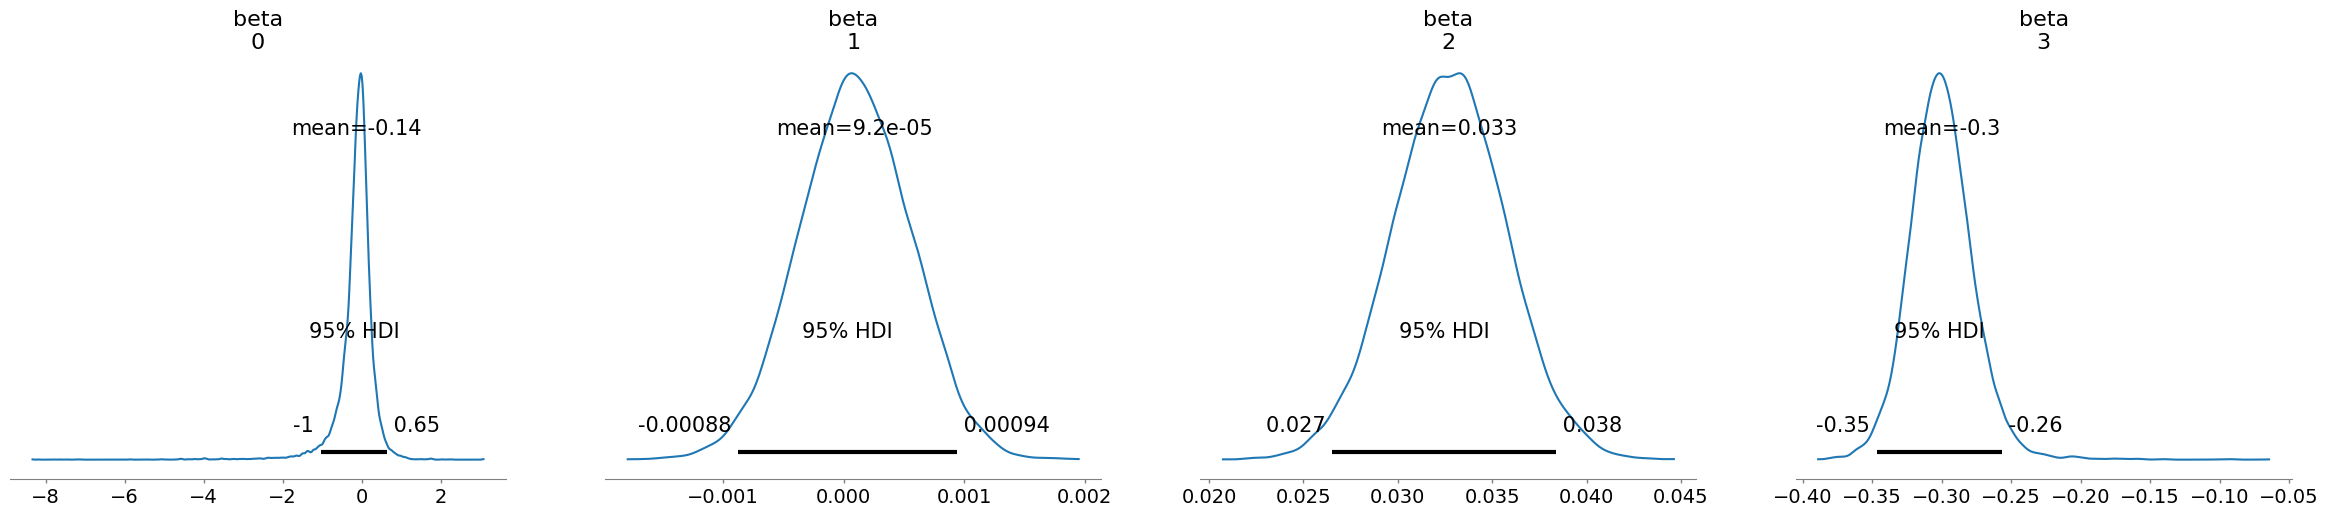

In [ ]:
#plot prior vs posterior for beta
az.plot_posterior(poi_glm_data, var_names=["beta"], hdi_prob=0.95)


In [ ]:
#IDEE:
#una volta che faccio sampling:
#posterior vs prior predictive checks
#posterior predictive checks
#ESS
#compute posterior mean 
#compute credible intervals

#TO DO
#provo a runnare
#scegliere bene le prior 